# 2048 AI Solvers
**Predmet:** Základy umelej inteligencie
**Solvers:** Random · Rule-based Heuristic · ExpectiMax
**Experiment:** 30 hier na solver — štatistika, vizualizácie, animácie, Excel export

---

## Sekcia 0 – Základ hry & Importy

In [1]:
# ══════════════════════════════════════════════════════════════════
# 0.1  Base game code – verbatim copy from 2048_base.ipynb
# ══════════════════════════════════════════════════════════════════
import numpy as np
import copy as cp

def add_score(sc, val):
    sc += val
    return sc

def move_left(grid, score):
    for i in range(4):
        non_zero = [x for x in grid[i, :] if x != 0]
        zero = [0] * (4 - len(non_zero))
        grid[i, :] = np.array(non_zero + zero)
        for j in range(3):
            if grid[i, j] == grid[i, j + 1]:
                grid[i, j] *= 2
                score = add_score(score, grid[i, j])
                grid[i, j + 1] = 0
        non_zero = [x for x in grid[i, :] if x != 0]
        zero = [0] * (4 - len(non_zero))
        grid[i, :] = np.array(non_zero + zero)
    return (grid, score)

def move_right(grid, score):
    for i in range(4):
        non_zero = [x for x in grid[i, :] if x != 0]
        zero = [0] * (4 - len(non_zero))
        grid[i, :] = np.array(zero + non_zero[::-1])
        for j in range(3, 0, -1):
            if grid[i, j] == grid[i, j - 1]:
                grid[i, j] *= 2
                score = add_score(score, grid[i, j])
                grid[i, j - 1] = 0
        non_zero = [x for x in grid[i, :] if x != 0]
        zero = [0] * (4 - len(non_zero))
        grid[i, :] = np.array(zero + non_zero[::-1])
    return (grid, score)

def move_up(grid, score):
    for i in range(4):
        non_zero = [x for x in grid[:, i] if x != 0]
        zero = [0] * (4 - len(non_zero))
        grid[:, i] = np.array(non_zero + zero)
        for j in range(3):
            if grid[j, i] == grid[j + 1, i]:
                grid[j, i] *= 2
                score = add_score(score, grid[j, i])
                grid[j + 1, i] = 0
        non_zero = [x for x in grid[:, i] if x != 0]
        zero = [0] * (4 - len(non_zero))
        grid[:, i] = np.array(non_zero + zero)
    return (grid, score)

def move_down(grid, score):
    for i in range(4):
        non_zero = [x for x in grid[:, i] if x != 0]
        zero = [0] * (4 - len(non_zero))
        grid[:, i] = np.array(zero + non_zero[::-1])
        for j in range(3, 0, -1):
            if grid[j, i] == grid[j - 1, i]:
                grid[j, i] *= 2
                score = add_score(score, grid[j, i])
                grid[j - 1, i] = 0
        non_zero = [x for x in grid[:, i] if x != 0]
        zero = [0] * (4 - len(non_zero))
        grid[:, i] = np.array(zero + non_zero[::-1])
    return (grid, score)

def add_new_number(grid):
    zero_indices = np.where(grid == 0)
    if len(zero_indices[0]) == 0:
        return False
    index = np.random.choice(len(zero_indices[0]))
    i, j = zero_indices[0][index], zero_indices[1][index]
    grid[i, j] = 2 if np.random.random() < 0.9 else 4
    return True

def check_game_over(grid):
    if np.all(grid) == False:
        return False
    for row in range(4):
        for col in range(4):
            if row != 3:
                if grid[row, col] == grid[row + 1, col]:
                    return False
            if col != 3:
                if grid[row, col] == grid[row, col + 1]:
                    return False
    return True

def check_win(grid):
    return 2048 in grid

def play_2048(grid, move, score):
    orig_grid = cp.deepcopy(grid)
    if check_game_over(grid):
        raise RuntimeError("GO")
    if move == 'left':
        grid, score = move_left(grid, score)
    elif move == 'right':
        grid, score = move_right(grid, score)
    elif move == 'up':
        grid, score = move_up(grid, score)
    elif move == 'down':
        grid, score = move_down(grid, score)
    else:
        raise ValueError("Invalid move")
    if check_win(grid):
        raise RuntimeError("WIN")
    if not np.array_equal(grid, orig_grid):
        add_new_number(grid)
    return (grid, score)

def new_game():
    score = 0
    grid = np.zeros((4, 4), dtype=int)
    add_new_number(grid)
    add_new_number(grid)
    return (grid, score)

def print_grid(grid, score):
    print('Score:', score)
    print("+----+----+----+----+")
    for i in range(4):
        line = "|"
        for j in range(4):
            if grid[i, j] == 0:
                line += "    |"
            else:
                line += "{:4d}|".format(grid[i, j])
        print(line)
        print("+----+----+----+----+")

print("Base game code loaded OK.")

Base game code loaded OK.


In [2]:
# ══════════════════════════════════════════════════════════════════
# 0.2  Additional imports
# ══════════════════════════════════════════════════════════════════
import random
import copy
import time

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Reproducibility seed – remove to get different results each run
np.random.seed(42)
random.seed(42)

print(f"NumPy {np.__version__} | Pandas {pd.__version__} | Matplotlib {matplotlib.__version__}")
print("All imports OK.")

NumPy 2.0.2 | Pandas 2.3.3 | Matplotlib 3.9.4
All imports OK.


## Sekcia 1 – Infraštruktúra & Harness

In [3]:
# ══════════════════════════════════════════════════════════════════
# 1.1  Game record factory + move helpers
# ══════════════════════════════════════════════════════════════════
MOVES = ['left', 'right', 'up', 'down']

def empty_game_record():
    return {
        'solver':       '',
        'score':        0,
        'max_tile':     0,
        'move_count':   0,
        'moves_left':   0,
        'moves_right':  0,
        'moves_up':     0,
        'moves_down':   0,
        'outcome':      '',      # 'win' | 'loss'
        'grid_history': [],      # list of (grid_copy, score) snapshots
    }

_MOVE_FNS = {
    'left':  move_left,
    'right': move_right,
    'up':    move_up,
    'down':  move_down,
}

def apply_move_to_copy(grid, score, move):
    """Apply move to a deep copy. Returns (new_grid, new_score)."""
    g = copy.deepcopy(grid)
    return _MOVE_FNS[move](g, score)

def is_valid_move(grid, score, move):
    """True if the move changes the board state."""
    g_new, _ = apply_move_to_copy(grid, score, move)
    return not np.array_equal(g_new, grid)

print("Infrastructure helpers loaded.")

Infrastructure helpers loaded.


In [4]:
# ══════════════════════════════════════════════════════════════════
# 1.2  Universal solver harness
# ══════════════════════════════════════════════════════════════════
def run_solver(solver_fn, n_games=30, record_history=True, verbose=True):
    """
    Run solver_fn for n_games games. Returns list of game_record dicts.
    solver_fn(grid, score) -> move string ('left'/'right'/'up'/'down') or None
    """
    records = []
    for game_i in range(n_games):
        rec = empty_game_record()
        grid, score = new_game()
        if record_history:
            rec['grid_history'].append((copy.deepcopy(grid), score))

        while True:
            move = solver_fn(grid, score)
            if move is None:
                rec['outcome'] = 'loss'
                break
            try:
                grid, score = play_2048(grid, move, score)
                rec[f'moves_{move}'] += 1
                rec['move_count'] += 1
                if record_history:
                    rec['grid_history'].append((copy.deepcopy(grid), score))
            except RuntimeError as e:
                msg = str(e)
                if msg == 'WIN':
                    rec['outcome'] = 'win'
                    rec[f'moves_{move}'] += 1
                    rec['move_count'] += 1
                    if record_history:
                        rec['grid_history'].append((copy.deepcopy(grid), score))
                else:  # 'GO'
                    rec['outcome'] = 'loss'
                break

        rec['score']    = score
        rec['max_tile'] = int(grid.max())
        records.append(rec)

        if verbose and (game_i + 1) % 10 == 0:
            wins_so_far = sum(r['outcome'] == 'win' for r in records)
            print(f"  [{game_i+1:2d}/{n_games}] score={score:6d}  max_tile={rec['max_tile']:4d}"
                  f"  outcome={rec['outcome']:4s}  wins_so_far={wins_so_far}")

    return records

print("run_solver harness loaded.")

run_solver harness loaded.


In [5]:
# ══════════════════════════════════════════════════════════════════
# 1.3  Shared board evaluation function (used by Heuristic + ExpectiMax)
# ══════════════════════════════════════════════════════════════════

def _log2(x):
    return float(np.log2(x)) if x > 0 else 0.0

def eval_monotonicity(grid):
    """Penalize non-monotone rows and columns (log2 scale, best direction)."""
    log_g = np.vectorize(_log2)(grid)
    total = 0.0
    for r in range(4):
        row = log_g[r, :]
        fwd = sum(max(row[i] - row[i+1], 0) for i in range(3))
        bwd = sum(max(row[i+1] - row[i], 0) for i in range(3))
        total -= min(fwd, bwd)
    for c in range(4):
        col = log_g[:, c]
        fwd = sum(max(col[i] - col[i+1], 0) for i in range(3))
        bwd = sum(max(col[i+1] - col[i], 0) for i in range(3))
        total -= min(fwd, bwd)
    return total

def eval_smoothness(grid):
    """Penalize adjacent tiles with very different values (hard future merges)."""
    log_g = np.vectorize(_log2)(grid)
    penalty = 0.0
    for r in range(4):
        for c in range(4):
            if grid[r, c] == 0:
                continue
            if c < 3 and grid[r, c+1] != 0:
                penalty -= abs(log_g[r, c] - log_g[r, c+1])
            if r < 3 and grid[r+1, c] != 0:
                penalty -= abs(log_g[r, c] - log_g[r+1, c])
    return penalty

def eval_empty(grid):
    """log2 of empty cell count – encourages keeping board open."""
    return float(np.log2(max(int(np.sum(grid == 0)), 1)))

def eval_corner(grid):
    """Bonus if max tile is in any corner."""
    max_val = int(grid.max())
    if max_val == 0:
        return 0.0
    corners = [int(grid[0,0]), int(grid[0,3]), int(grid[3,0]), int(grid[3,3])]
    return _log2(max_val) if max_val in corners else 0.0

MONO_W   = 1.0
SMOOTH_W = 0.1
EMPTY_W  = 2.7
CORNER_W = 1.0

def evaluate(grid):
    """Combined board evaluation (higher = better position)."""
    return (MONO_W   * eval_monotonicity(grid)
          + SMOOTH_W * eval_smoothness(grid)
          + EMPTY_W  * eval_empty(grid)
          + CORNER_W * eval_corner(grid))

print("Evaluation function loaded (shared by Heuristic + ExpectiMax).")

Evaluation function loaded (shared by Heuristic + ExpectiMax).


## Sekcia 2 – Solver 1: Random Baseline

Náhodný solver vyberá **uniformne náhodný platný ťah** (taký ktorý zmení stav plochy).
Filtruje neplatné ťahy aby sa vyhol nekonečným cyklom.
Slúži ako **referenčná baseline** – žiadna stratégia, len náhoda.

In [6]:
# ══════════════════════════════════════════════════════════════════
# 2.1  Random solver
# ══════════════════════════════════════════════════════════════════
def random_solver(grid, score):
    valid = [m for m in MOVES if is_valid_move(grid, score, m)]
    return random.choice(valid) if valid else None

print("Random solver loaded.")

Random solver loaded.


In [7]:
# 2.2  Run 30 games
np.random.seed(42); random.seed(42)
print("Running 30 games – Random solver...")
t0 = time.time()
random_records = run_solver(random_solver, n_games=30, record_history=True)
t1 = time.time()
wins_r = sum(r['outcome'] == 'win' for r in random_records)
avg_r  = np.mean([r['score'] for r in random_records])
print(f"\nDone in {t1-t0:.1f}s | Wins: {wins_r}/30 | Avg score: {avg_r:.0f}")

Running 30 games – Random solver...
  [10/30] score=  2428  max_tile= 256  outcome=loss  wins_so_far=0
  [20/30] score=  1356  max_tile= 128  outcome=loss  wins_so_far=0
  [30/30] score=   988  max_tile= 128  outcome=loss  wins_so_far=0

Done in 1.0s | Wins: 0/30 | Avg score: 1143


## Sekcia 3 – Solver 2: Rule-Based Heuristic

### Stratégia: Greedy 1-ply Evaluation

Solver vyhodnotí **všetky 4 platné ťahy** pomocou ručne navrhnutej eval funkcie
a vyberie ten, ktorý vedie k **najlepšiemu okamžitému stavu** plochy.

Eval funkcia (tá istá ako v ExpectiMax): monotonicity + smoothness + empty_cells + corner_bonus

Toto je **greedy best-first** prístup – 1 úroveň dopredu, bez stromu pravdepodobnosti.
**Stále je to rule-based AI:** eval funkcia je ručne navrhnutá, žiadne učenie, žiadny strom.

```
Poradie hodnotenia pre každý ťah:
move → apply_move_to_copy → evaluate(new_grid) → vyber max
```

Výhoda oproti pevnému poradiu: solver sa dynamicky prispôsobuje stavu plochy
a využíva všetky 4 smery podľa potreby.

In [8]:
# ══════════════════════════════════════════════════════════════════
# 3.1  Rule-based heuristic solver – greedy 1-ply evaluation
# ══════════════════════════════════════════════════════════════════

def heuristic_solver(grid, score):
    """
    Greedy 1-ply heuristic: evaluates all valid moves via evaluate()
    and returns the move leading to the highest-scoring immediate board state.
    Rule-based (hand-crafted eval function, no tree search, no ML).
    """
    best_move, best_val = None, -float('inf')
    for move in MOVES:
        if not is_valid_move(grid, score, move):
            continue
        g_new, _ = apply_move_to_copy(grid, score, move)
        val = evaluate(g_new)
        if val > best_val:
            best_val, best_move = val, move
    return best_move

print("Heuristic solver loaded (greedy 1-ply evaluation).")

Heuristic solver loaded (greedy 1-ply evaluation).


In [9]:
# 3.2  Run 30 games
np.random.seed(42); random.seed(42)
print("Running 30 games – Heuristic solver...")
t0 = time.time()
heuristic_records = run_solver(heuristic_solver, n_games=30, record_history=True)
t1 = time.time()
wins_h = sum(r['outcome'] == 'win' for r in heuristic_records)
avg_h  = np.mean([r['score'] for r in heuristic_records])
print(f"\nDone in {t1-t0:.1f}s | Wins: {wins_h}/30 | Avg score: {avg_h:.0f}")

Running 30 games – Heuristic solver...
  [10/30] score=  7516  max_tile= 512  outcome=loss  wins_so_far=0
  [20/30] score=  5520  max_tile= 512  outcome=loss  wins_so_far=0
  [30/30] score=  3940  max_tile= 256  outcome=loss  wins_so_far=0

Done in 14.6s | Wins: 0/30 | Avg score: 7225


## Sekcia 4 – Solver 3: ExpectiMax

### Teória

ExpectiMax je rozšírenie Minimax pre **stochastické hry** (hry s náhodnosťou).
Strom sa skladá z dvoch typov uzlov:

| Typ uzla | Hráč | Akcia |
|----------|------|-------|
| **Max-uzol** | AI | Vyberie ťah s najvyššou očakávanou hodnotou |
| **Chance-uzol** | Náhoda | Váhovaný priemer cez všetky možné spawny dlaždíc |

Pravdepodobnosti spawnu: **P(2) = 0.9**, **P(4) = 0.1**
Každé prázdne políčko je rovnako pravdepodobné → delíme `len(empty_cells)`

### Heuristická funkcia (evaluation)

Hodnotí listový stav kombináciou 4 komponentov (všetko v **log₂ škále**):

| Komponent | Váha | Popis |
|-----------|------|-------|
| Monotonicity | 1.0 | Odmeňuje monotónne klesajúce riadky/stĺpce od rohu |
| Smoothness | 0.1 | Odmeňuje susedné dlaždice s podobnými hodnotami (ľahké merge) |
| Empty cells | 2.7 | log₂(počet prázdnych) – kľúčové pre prežitie |
| Corner bonus | 1.0 | Bonus ak max dlaždica je v niektorom rohu |

### Hĺbka stromu

`BASE_DEPTH = 3` normálne, `CRITICAL_DEPTH = 4` keď ≤4 prázdne políčka
→ lepšie rozhodnutia v najkritickejšej fáze hry (5 z 6 prehier nastalo práve tu)

In [10]:
# ══════════════════════════════════════════════════════════════════
# 4.1  Evaluation function – defined in Section 1 (shared infrastructure)
# ══════════════════════════════════════════════════════════════════
# eval_monotonicity, eval_smoothness, eval_empty, eval_corner, evaluate
# are defined above in Section 1.3 so they can be reused by both
# the Heuristic solver (Section 3) and ExpectiMax (Section 4).

print(f"Evaluation weights: MONO={MONO_W}, SMOOTH={SMOOTH_W}, EMPTY={EMPTY_W}, CORNER={CORNER_W}")

Evaluation weights: MONO=1.0, SMOOTH=0.1, EMPTY=2.7, CORNER=1.0


In [11]:
# ══════════════════════════════════════════════════════════════════
# 4.2  ExpectiMax tree search
# ══════════════════════════════════════════════════════════════════

def expectimax(grid, score, depth, is_max_node):
    """
    Recursive ExpectiMax.
    depth=0  → leaf: return evaluate(grid)
    Max node → maximize over valid moves
    Chance node → weighted average over empty-cell × tile-value combos
    """
    if depth == 0:
        return evaluate(grid)

    if is_max_node:
        best = -float('inf')
        any_valid = False
        for move in MOVES:
            g_new, s_new = apply_move_to_copy(grid, score, move)
            if np.array_equal(g_new, grid):
                continue
            any_valid = True
            val = expectimax(g_new, s_new, depth - 1, False)
            if val > best:
                best = val
        return best if any_valid else evaluate(grid)

    else:
        # Chance node: average over empty positions, weight by tile probability
        empty_pos = list(zip(*np.where(grid == 0)))
        if not empty_pos:
            return evaluate(grid)
        total = 0.0
        for (r, c) in empty_pos:
            for tile_val, prob in ((2, 0.9), (4, 0.1)):
                g_copy = copy.deepcopy(grid)
                g_copy[r, c] = tile_val
                total += prob * expectimax(g_copy, score, depth - 1, True)
        # Each empty cell is equally likely to receive the new tile
        return total / len(empty_pos)

print("ExpectiMax tree loaded.")

ExpectiMax tree loaded.


In [12]:
# ══════════════════════════════════════════════════════════════════
# 4.3  ExpectiMax solver wrapper – adaptive depth
# ══════════════════════════════════════════════════════════════════

BASE_DEPTH         = 3   # normal game phase
CRITICAL_DEPTH     = 4   # endgame: ≤ CRITICAL_THRESHOLD empty cells
CRITICAL_THRESHOLD = 2   # depth-4 only in last critical moves (≤2 empty cells)

def expectimax_solver(grid, score):
    """
    Adaptive-depth ExpectiMax.
    Uses BASE_DEPTH=3 normally; deepens to CRITICAL_DEPTH=4 when
    CRITICAL_THRESHOLD or fewer empty cells remain — critical endgame phase
    where depth-3 previously caused the majority of losses.
    """
    empty_count = int(np.sum(grid == 0))
    depth = CRITICAL_DEPTH if empty_count <= CRITICAL_THRESHOLD else BASE_DEPTH

    best_move = None
    best_val  = -float('inf')
    for move in MOVES:
        g_new, s_new = apply_move_to_copy(grid, score, move)
        if np.array_equal(g_new, grid):
            continue
        val = expectimax(g_new, s_new, depth - 1, is_max_node=False)
        if val > best_val:
            best_val  = val
            best_move = move
    return best_move

print(f"ExpectiMax solver loaded (base={BASE_DEPTH}, critical={CRITICAL_DEPTH} when ≤{CRITICAL_THRESHOLD} empty).")

ExpectiMax solver loaded (base=3, critical=4 when ≤2 empty).


In [13]:
# 4.4  Run 30 games
np.random.seed(42); random.seed(42)
print("Running 30 games – ExpectiMax solver (may take 2–5 min)...")
t0 = time.time()
expectimax_records = run_solver(expectimax_solver, n_games=30, record_history=True)
t1 = time.time()
wins_e = sum(r['outcome'] == 'win' for r in expectimax_records)
avg_e  = np.mean([r['score'] for r in expectimax_records])
print(f"\nDone in {t1-t0:.1f}s | Wins: {wins_e}/30 | Avg score: {avg_e:.0f}")

Running 30 games – ExpectiMax solver (may take 2–5 min)...


  [10/30] score= 18544  max_tile=2048  outcome=win   wins_so_far=6


  [20/30] score= 18272  max_tile=2048  outcome=win   wins_so_far=13


  [30/30] score= 19396  max_tile=2048  outcome=win   wins_so_far=19

Done in 1106.4s | Wins: 19/30 | Avg score: 17990


## Sekcia 5 – Štatistiky & Excel Export

In [14]:
# ══════════════════════════════════════════════════════════════════
# 5.1  Aggregate statistics per solver
# ══════════════════════════════════════════════════════════════════

def compute_stats(records, solver_name):
    scores    = [r['score']      for r in records]
    max_tiles = [r['max_tile']   for r in records]
    moves     = [r['move_count'] for r in records]
    wins      = sum(r['outcome'] == 'win'  for r in records)
    losses    = sum(r['outcome'] == 'loss' for r in records)
    n         = len(records)
    return {
        'solver':            solver_name,
        'n_games':           n,
        'best_score':        int(max(scores)),
        'worst_score':       int(min(scores)),
        'avg_score':         round(float(np.mean(scores)),  1),
        'median_score':      round(float(np.median(scores)), 1),
        'std_score':         round(float(np.std(scores)),   1),
        'wins':              wins,
        'losses':            losses,
        'win_rate_%':        round(100 * wins / n, 1),
        'avg_max_tile':      round(float(np.mean(max_tiles)), 1),
        'max_tile_reached':  int(max(max_tiles)),
        'avg_moves_total':   round(float(np.mean(moves)),           1),
        'avg_moves_left':    round(float(np.mean([r['moves_left']  for r in records])), 1),
        'avg_moves_right':   round(float(np.mean([r['moves_right'] for r in records])), 1),
        'avg_moves_up':      round(float(np.mean([r['moves_up']    for r in records])), 1),
        'avg_moves_down':    round(float(np.mean([r['moves_down']  for r in records])), 1),
    }

stats_r = compute_stats(random_records,     'Random')
stats_h = compute_stats(heuristic_records,  'Heuristic')
stats_e = compute_stats(expectimax_records, 'ExpectiMax')

summary_df = pd.DataFrame([stats_r, stats_h, stats_e])
print("=== SUMMARY – 30 games per solver ===")
display(summary_df.set_index('solver'))

=== SUMMARY – 30 games per solver ===


,n_games,best_score,worst_score,avg_score,median_score,std_score,wins,losses,win_rate_%,avg_max_tile,max_tile_reached,avg_moves_total,avg_moves_left,avg_moves_right,avg_moves_up,avg_moves_down
solver,,,,,,,,,,,,,,,,
Random,30,2504,256,1142.9,1016.0,622.5,0,30,0.0,120.5,256,119.5,29.2,29.7,30.1,30.5
Heuristic,30,16616,1832,7224.5,6454.0,4066.4,0,30,0.0,533.3,1024,491.7,180.8,80.8,169.3,60.8
ExpectiMax,30,20636,12928,17989.6,18328.0,1512.6,19,11,63.3,1672.5,2048,994.7,262.7,240.2,287.2,204.7


In [15]:
# 5.2  Per-game DataFrames
def records_to_df(records, solver_name):
    rows = []
    for i, r in enumerate(records):
        total = max(r['move_count'], 1)
        rows.append({
            'game':              i + 1,
            'solver':            solver_name,
            'score':             r['score'],
            'max_tile':          r['max_tile'],
            'move_count':        r['move_count'],
            'moves_left':        r['moves_left'],
            'moves_right':       r['moves_right'],
            'moves_up':          r['moves_up'],
            'moves_down':        r['moves_down'],
            'pct_left':          round(100 * r['moves_left']  / total, 1),
            'pct_right':         round(100 * r['moves_right'] / total, 1),
            'pct_up':            round(100 * r['moves_up']    / total, 1),
            'pct_down':          round(100 * r['moves_down']  / total, 1),
            'outcome':           r['outcome'],
        })
    return pd.DataFrame(rows)

df_r = records_to_df(random_records,     'Random')
df_h = records_to_df(heuristic_records,  'Heuristic')
df_e = records_to_df(expectimax_records, 'ExpectiMax')
all_df = pd.concat([df_r, df_h, df_e], ignore_index=True)
print(f"Per-game DataFrames: {len(all_df)} rows total.")

Per-game DataFrames: 90 rows total.


In [16]:
# 5.3  Excel export
import os
EXCEL_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')), '2048_results.xlsx')
EXCEL_PATH = '/Users/admin/Desktop/ZUI/2048_results.xlsx'

with pd.ExcelWriter(EXCEL_PATH, engine='openpyxl') as writer:
    summary_df.to_excel(writer, sheet_name='Summary',    index=False)
    df_r.to_excel(      writer, sheet_name='Random',     index=False)
    df_h.to_excel(      writer, sheet_name='Heuristic',  index=False)
    df_e.to_excel(      writer, sheet_name='ExpectiMax', index=False)
    all_df.to_excel(    writer, sheet_name='All_Games',  index=False)

print(f"Saved: {EXCEL_PATH}")
print("Sheets: Summary | Random | Heuristic | ExpectiMax | All_Games")

Saved: /Users/admin/Desktop/ZUI/2048_results.xlsx
Sheets: Summary | Random | Heuristic | ExpectiMax | All_Games


## Sekcia 6 – Vizualizácie

In [17]:
# ══════════════════════════════════════════════════════════════════
# 6.0  Color palettes
# ══════════════════════════════════════════════════════════════════
BASE_PATH = '/Users/admin/Desktop/ZUI/'

TILE_COLORS = {
    0: '#cdc1b4', 2: '#eee4da', 4: '#ede0c8',
    8: '#f2b179', 16: '#f59563', 32: '#f67c5f',
    64: '#f65e3b', 128: '#edcf72', 256: '#edcc61',
    512: '#edc850', 1024: '#edc53f', 2048: '#edc22e',
}
TEXT_COLORS = {k: '#776e65' if k in (0,2,4) else '#f9f6f2' for k in TILE_COLORS}

SOLVER_COLORS = {'Random': '#4c72b0', 'Heuristic': '#dd8452', 'ExpectiMax': '#55a868'}
SOLVER_NAMES  = ['Random', 'Heuristic', 'ExpectiMax']
DFS_LIST      = [df_r, df_h, df_e]
STATS_LIST    = [stats_r, stats_h, stats_e]

print("Color palettes loaded.")

Color palettes loaded.


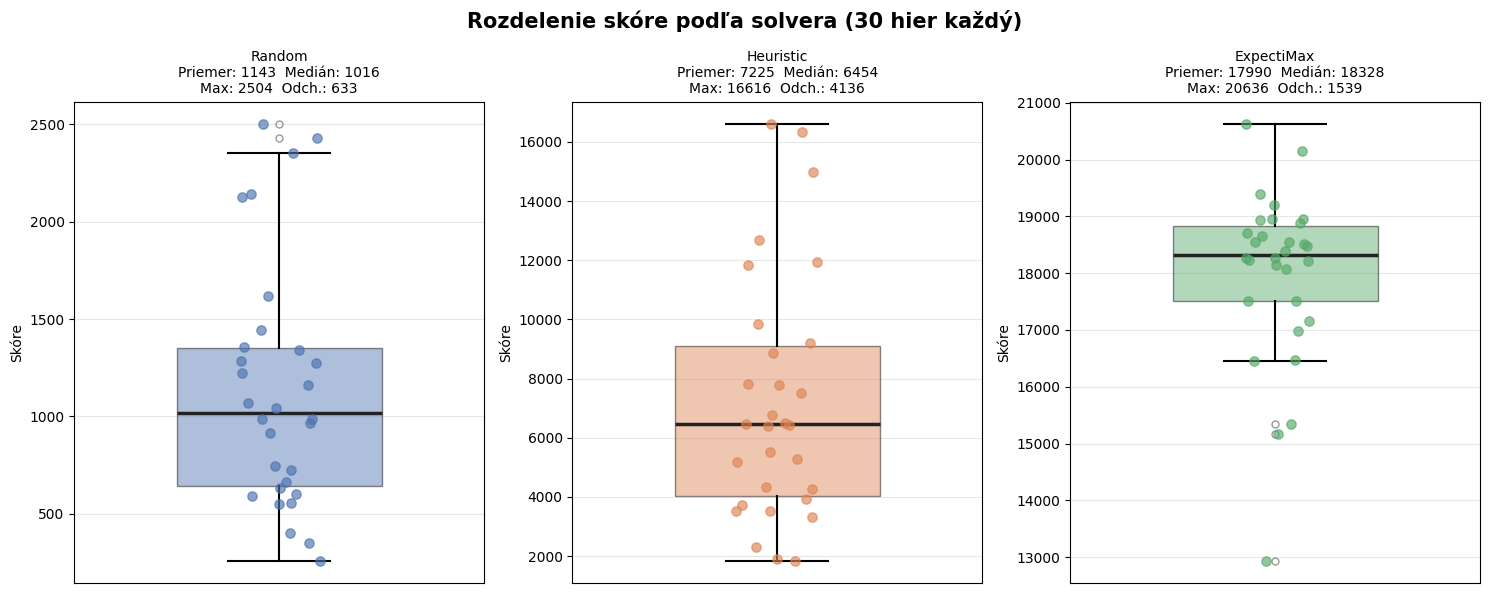

Uložené: score_distribution.png


In [18]:
# ── Graf 1: Rozdelenie skóre (box + strip) ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Rozdelenie skóre podľa solvera (30 hier každý)',
             fontsize=15, fontweight='bold')

for ax, name, df in zip(axes, SOLVER_NAMES, DFS_LIST):
    col = SOLVER_COLORS[name]
    ax.boxplot(df['score'], patch_artist=True, widths=0.5,
               boxprops=dict(facecolor=col, alpha=0.45),
               medianprops=dict(color='#222222', linewidth=2.5),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5),
               flierprops=dict(marker='o', markersize=5, alpha=0.4, color=col))
    jitter = np.random.uniform(-0.1, 0.1, len(df))
    ax.scatter(1 + jitter, df['score'], alpha=0.65, color=col, s=45, zorder=3)
    ax.set_title(
        f'{name}\n'
        f'Priemer: {df["score"].mean():.0f}  Medián: {df["score"].median():.0f}\n'
        f'Max: {df["score"].max()}  Odch.: {df["score"].std():.0f}',
        fontsize=10)
    ax.set_ylabel('Skóre', fontsize=10)
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_PATH + 'score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Uložené: score_distribution.png")

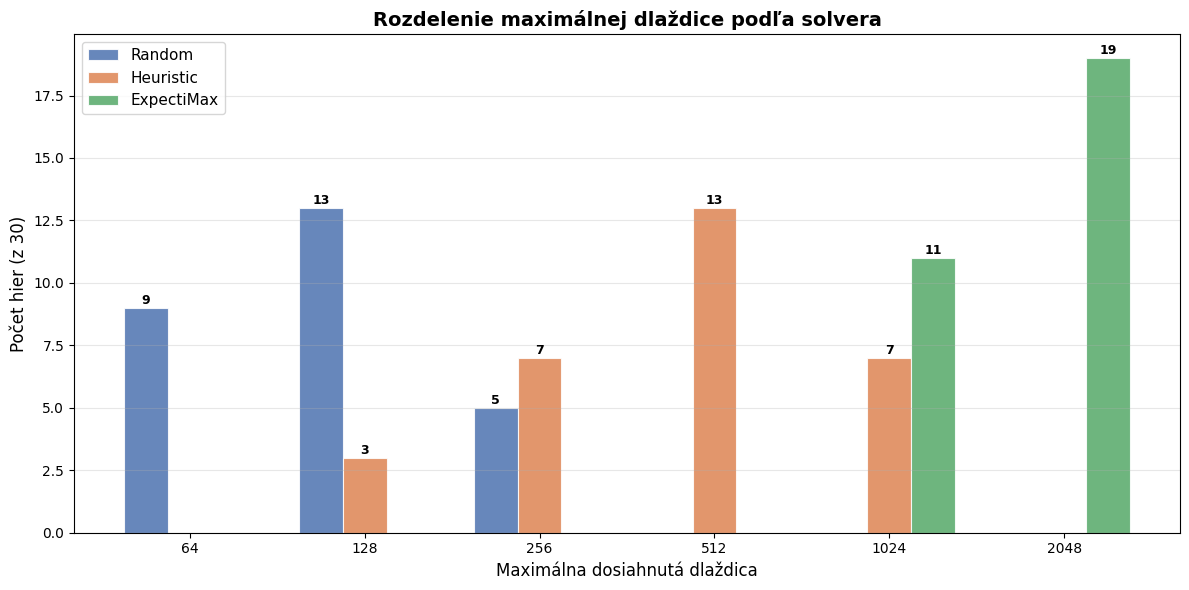

Uložené: max_tile_distribution.png


In [19]:
# ── Graf 2: Rozdelenie max. dlaždice (grouped bar) ──────────────
tile_vals = [64, 128, 256, 512, 1024, 2048]
x = np.arange(len(tile_vals))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, df) in enumerate(zip(SOLVER_NAMES, DFS_LIST)):
    counts = [int(np.sum(df['max_tile'] == t)) for t in tile_vals]
    bars = ax.bar(x + i*width, counts, width, label=name,
                  color=SOLVER_COLORS[name], alpha=0.85, edgecolor='white', linewidth=0.8)
    for bar, cnt in zip(bars, counts):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    str(cnt), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels([str(t) for t in tile_vals])
ax.set_xlabel('Maximálna dosiahnutá dlaždica', fontsize=12)
ax.set_ylabel('Počet hier (z 30)', fontsize=12)
ax.set_title('Rozdelenie maximálnej dlaždice podľa solvera', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_PATH + 'max_tile_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Uložené: max_tile_distribution.png")

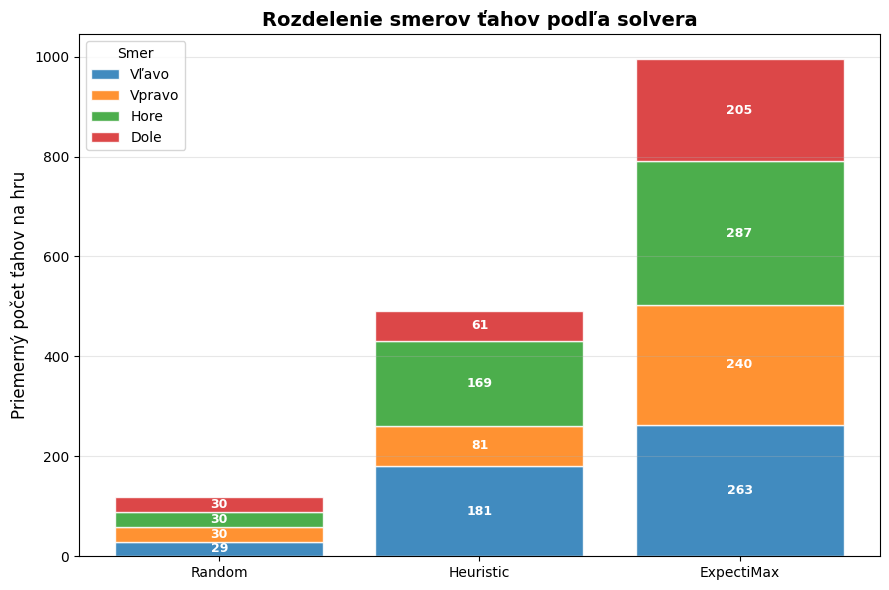

Uložené: move_directions.png


In [20]:
# ── Graf 3: Rozdelenie smerov ťahov (stacked bar) ───────────────
directions     = ['left', 'right', 'up', 'down']
dir_labels_sk  = ['Vľavo', 'Vpravo', 'Hore', 'Dole']
dir_colors     = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(9, 6))
bottom = np.zeros(3)
for d, lbl, dc in zip(directions, dir_labels_sk, dir_colors):
    vals = np.array([s[f'avg_moves_{d}'] for s in STATS_LIST])
    bars = ax.bar(SOLVER_NAMES, vals, bottom=bottom, label=lbl,
                  color=dc, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        if val > 8:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.0f}', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('Priemerný počet ťahov na hru', fontsize=12)
ax.set_title('Rozdelenie smerov ťahov podľa solvera', fontsize=14, fontweight='bold')
ax.legend(title='Smer', loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_PATH + 'move_directions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Uložené: move_directions.png")

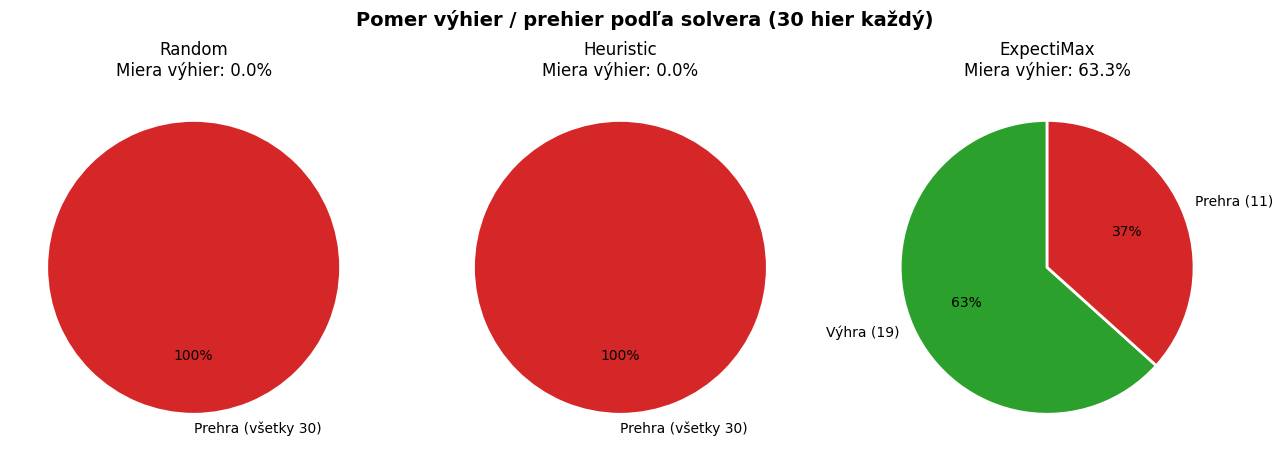

Uložené: win_loss.png


In [21]:
# ── Graf 4: Pomer výhier/prehier (pie) ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Pomer výhier / prehier podľa solvera (30 hier každý)',
             fontsize=14, fontweight='bold')

for ax, name, s in zip(axes, SOLVER_NAMES, STATS_LIST):
    if s['wins'] > 0:
        sizes  = [s['wins'], s['losses']]
        labels = [f'Výhra ({s["wins"]})', f'Prehra ({s["losses"]})']
        colors = ['#2ca02c', '#d62728']
    else:
        sizes  = [1]
        labels = [f'Prehra (všetky {s["losses"]})']
        colors = ['#d62728']
    ax.pie(sizes, labels=labels, colors=colors,
           autopct='%1.0f%%', startangle=90,
           wedgeprops=dict(edgecolor='white', linewidth=2))
    ax.set_title(f'{name}\nMiera výhier: {s["win_rate_%"]}%', fontsize=12)

plt.tight_layout()
plt.savefig(BASE_PATH + 'win_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Uložené: win_loss.png")

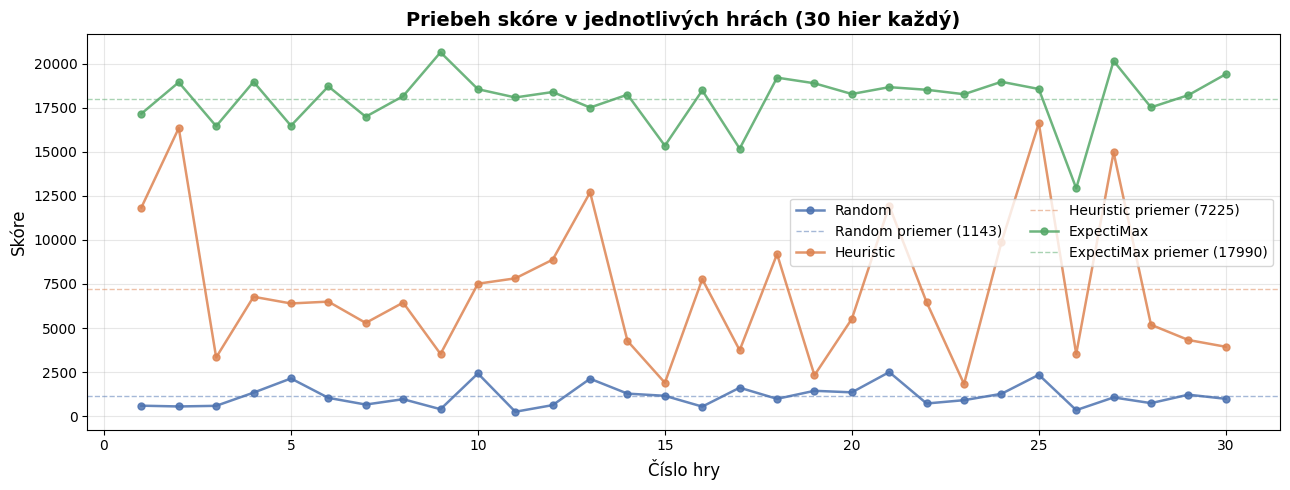

Uložené: score_progression.png


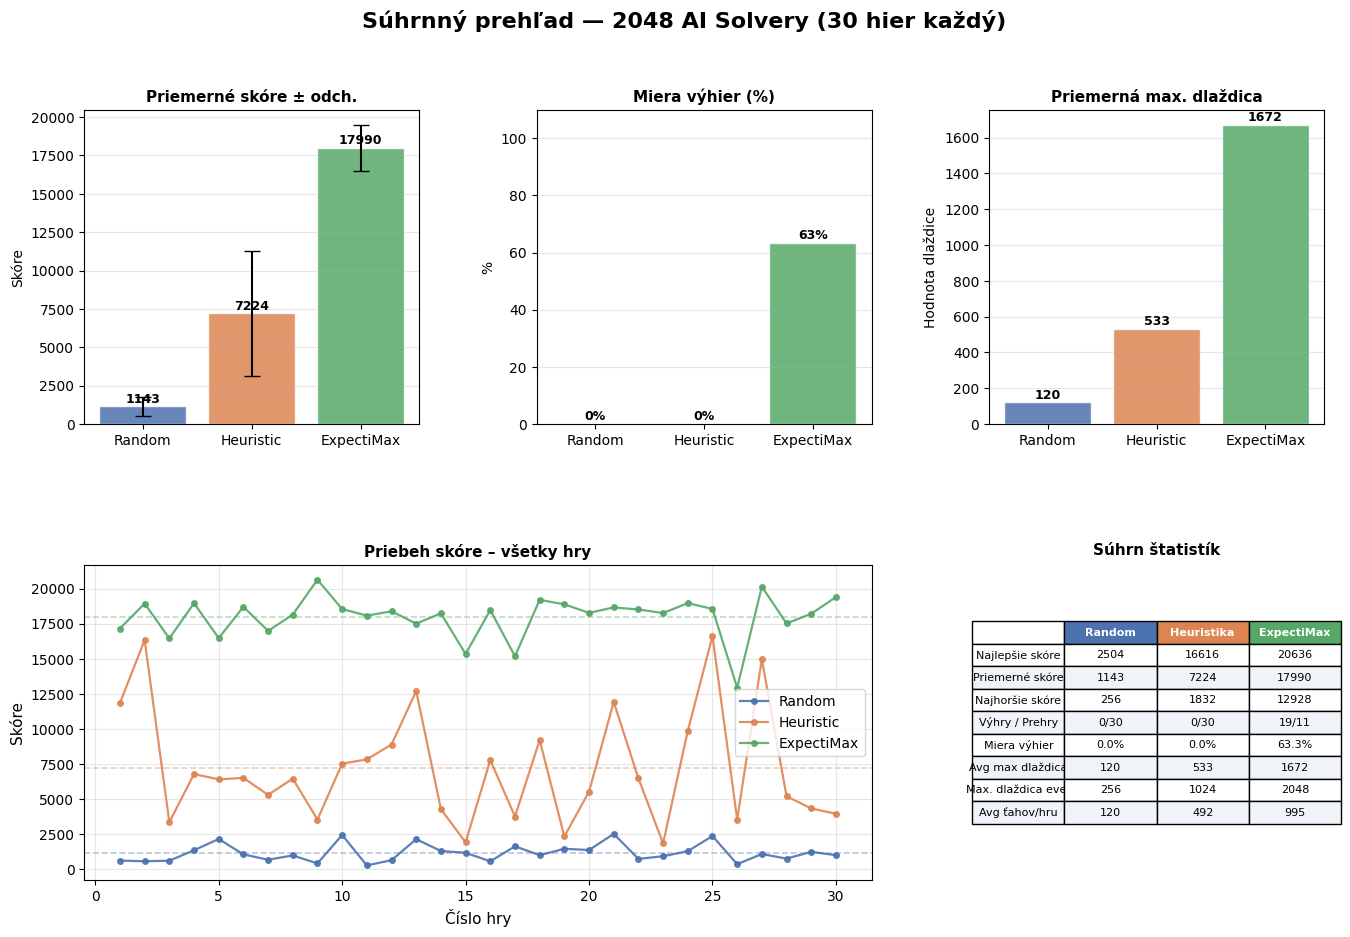

Uložené: score_progression.png + dashboard.png


In [22]:
# ── Graf 5: Priebeh skóre v jednotlivých hrách ──────────────────
fig, ax = plt.subplots(figsize=(13, 5))
game_nums = list(range(1, 31))

for name, df in zip(SOLVER_NAMES, DFS_LIST):
    col = SOLVER_COLORS[name]
    ax.plot(game_nums, df['score'].tolist(), marker='o', markersize=5,
            linewidth=1.8, color=col, label=name, alpha=0.85)
    avg_score = df['score'].mean()
    ax.axhline(avg_score, color=col, linestyle='--', linewidth=1, alpha=0.5,
               label=f'{name} priemer ({avg_score:.0f})')

ax.set_xlabel('Číslo hry', fontsize=12)
ax.set_ylabel('Skóre', fontsize=12)
ax.set_title('Priebeh skóre v jednotlivých hrách (30 hier každý)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_PATH + 'score_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Uložené: score_progression.png")

# ── Graf 6 (WOW): Súhrnný dashboard ─────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Súhrnný prehľad — 2048 AI Solvery (30 hier každý)',
             fontsize=16, fontweight='bold', y=0.98)

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# Panel A – priemerné skóre (bar)
ax_a = fig.add_subplot(gs[0, 0])
avgs  = [s['avg_score']  for s in STATS_LIST]
stds  = [s['std_score']  for s in STATS_LIST]
cols  = [SOLVER_COLORS[n] for n in SOLVER_NAMES]
bars  = ax_a.bar(SOLVER_NAMES, avgs, color=cols, alpha=0.85,
                 yerr=stds, capsize=6, edgecolor='white')
for bar, val in zip(bars, avgs):
    ax_a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
              f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_a.set_title('Priemerné skóre ± odch.', fontsize=11, fontweight='bold')
ax_a.set_ylabel('Skóre')
ax_a.grid(axis='y', alpha=0.3)

# Panel B – miera výhier
ax_b = fig.add_subplot(gs[0, 1])
win_rates = [s['win_rate_%'] for s in STATS_LIST]
bars2 = ax_b.bar(SOLVER_NAMES, win_rates, color=cols, alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, win_rates):
    ax_b.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
              f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_b.set_title('Miera výhier (%)', fontsize=11, fontweight='bold')
ax_b.set_ylabel('%')
ax_b.set_ylim(0, 110)
ax_b.grid(axis='y', alpha=0.3)

# Panel C – priemerná max dlaždica
ax_c = fig.add_subplot(gs[0, 2])
avg_tiles = [s['avg_max_tile'] for s in STATS_LIST]
bars3 = ax_c.bar(SOLVER_NAMES, avg_tiles, color=cols, alpha=0.85, edgecolor='white')
for bar, val in zip(bars3, avg_tiles):
    ax_c.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
              f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_c.set_title('Priemerná max. dlaždica', fontsize=11, fontweight='bold')
ax_c.set_ylabel('Hodnota dlaždice')
ax_c.grid(axis='y', alpha=0.3)

# Panel D – priebeh skóre (všetky hry)
ax_d = fig.add_subplot(gs[1, :2])
g_nums = list(range(1, 31))
for name, df in zip(SOLVER_NAMES, DFS_LIST):
    col = SOLVER_COLORS[name]
    ax_d.plot(g_nums, df['score'].tolist(), marker='o', markersize=4,
              linewidth=1.6, color=col, label=name, alpha=0.9)
    ax_d.axhline(df['score'].mean(), color=col, linestyle='--',
                 linewidth=1.2, alpha=0.4)
ax_d.set_xlabel('Číslo hry', fontsize=11)
ax_d.set_ylabel('Skóre', fontsize=11)
ax_d.set_title('Priebeh skóre – všetky hry', fontsize=11, fontweight='bold')
ax_d.legend(fontsize=10)
ax_d.grid(alpha=0.3)

# Panel E – štatistická tabuľka
ax_e = fig.add_subplot(gs[1, 2])
ax_e.axis('off')
tbl_data = [
    ['Metrika', 'Random', 'Heuristika', 'ExpectiMax'],
    ['Najlepšie skóre',
     str(stats_r['best_score']), str(stats_h['best_score']), str(stats_e['best_score'])],
    ['Priemerné skóre',
     f'{stats_r["avg_score"]:.0f}', f'{stats_h["avg_score"]:.0f}', f'{stats_e["avg_score"]:.0f}'],
    ['Najhoršie skóre',
     str(stats_r['worst_score']), str(stats_h['worst_score']), str(stats_e['worst_score'])],
    ['Výhry / Prehry',
     f'{stats_r["wins"]}/{stats_r["losses"]}',
     f'{stats_h["wins"]}/{stats_h["losses"]}',
     f'{stats_e["wins"]}/{stats_e["losses"]}'],
    ['Miera výhier',
     f'{stats_r["win_rate_%"]}%', f'{stats_h["win_rate_%"]}%', f'{stats_e["win_rate_%"]}%'],
    ['Avg max dlaždica',
     f'{stats_r["avg_max_tile"]:.0f}', f'{stats_h["avg_max_tile"]:.0f}', f'{stats_e["avg_max_tile"]:.0f}'],
    ['Max. dlaždica ever',
     str(stats_r['max_tile_reached']), str(stats_h['max_tile_reached']), str(stats_e['max_tile_reached'])],
    ['Avg ťahov/hru',
     f'{stats_r["avg_moves_total"]:.0f}', f'{stats_h["avg_moves_total"]:.0f}', f'{stats_e["avg_moves_total"]:.0f}'],
]
tbl = ax_e.table(cellText=tbl_data[1:], colLabels=tbl_data[0],
                 loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.1, 1.35)
# Farby hlavičky
for j in range(4):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
# Farby stĺpcov solverov
solver_header_colors = ['#ffffff', '#4c72b0', '#dd8452', '#55a868']
for j, col_hex in enumerate(solver_header_colors):
    tbl[0, j].set_facecolor(col_hex)
for i in range(1, len(tbl_data)):
    for j in range(4):
        tbl[i, j].set_facecolor('#f0f4f8' if i % 2 == 0 else '#ffffff')
ax_e.set_title('Súhrn štatistík', fontsize=11, fontweight='bold', pad=8)

plt.savefig(BASE_PATH + 'dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Uložené: score_progression.png + dashboard.png")

## Sekcia 7 – Animované Replaye

In [23]:
# ══════════════════════════════════════════════════════════════════
# 7.1  Grid drawing helper
# ══════════════════════════════════════════════════════════════════

def draw_grid_on_ax(ax, grid, score, title='', step=0, total_steps=0):
    ax.clear()
    ax.set_xlim(0, 4); ax.set_ylim(0, 4)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_facecolor('#bbada0')
    fig = ax.get_figure()
    fig.patch.set_facecolor('#faf8ef')

    for r in range(4):
        for c in range(4):
            val = int(grid[r, c])
            bg  = TILE_COLORS.get(val, '#3c3a32')
            rect = Rectangle([c + 0.05, 3 - r + 0.05], 0.90, 0.90,
                              facecolor=bg, edgecolor='#bbada0', linewidth=2, zorder=1)
            ax.add_patch(rect)
            if val != 0:
                tc = TEXT_COLORS.get(val, '#f9f6f2')
                fs = 22 if val < 100 else (17 if val < 1000 else 13)
                ax.text(c + 0.5, 3 - r + 0.5, str(val),
                        ha='center', va='center', fontsize=fs,
                        fontweight='bold', color=tc, zorder=2)

    step_str = f'  [ťah {step}/{total_steps}]' if total_steps > 0 else ''
    ax.set_title(f'{title}   Skóre: {score}{step_str}',
                 fontsize=11, pad=6, fontweight='bold', color='#776e65')

print("draw_grid_on_ax loaded.")

draw_grid_on_ax loaded.


In [24]:
# ══════════════════════════════════════════════════════════════════
# 7.2  Animation function
# ══════════════════════════════════════════════════════════════════

def best_game_index(records):
    return max(range(len(records)), key=lambda i: records[i]['score'])

def animate_game(records, solver_name, game_index=None,
                 output_file=None, interval=150, max_frames=400):
    if game_index is None:
        game_index = best_game_index(records)

    history = records[game_index]['grid_history']
    if not history:
        print(f"No history for game {game_index}.")
        return None

    # Subsample long games
    frames = list(range(len(history)))
    if max_frames and len(frames) > max_frames:
        step = max(len(frames) // max_frames, 1)
        frames = frames[::step]
        if frames[-1] != len(history) - 1:
            frames.append(len(history) - 1)

    fig, ax = plt.subplots(figsize=(5, 5.5))
    fig.patch.set_facecolor('#faf8ef')

    def update(fi):
        real = frames[fi]
        g, s = history[real]
        draw_grid_on_ax(ax, g, s, title=solver_name,
                        step=real, total_steps=len(history)-1)

    anim = animation.FuncAnimation(fig, update, frames=len(frames),
                                   interval=interval, repeat=False)

    if output_file:
        if output_file.endswith('.gif'):
            anim.save(output_file, writer=animation.PillowWriter(fps=7))
        elif output_file.endswith('.mp4'):
            anim.save(output_file, writer='ffmpeg', fps=7)
        final_score = records[game_index]['score']
        print(f"Saved: {output_file}  (game #{game_index+1}, "
              f"{len(frames)} frames, final score={final_score})")
        plt.close(fig)
    else:
        plt.close(fig)
        return HTML(anim.to_jshtml())

    return anim

print("animate_game loaded.")

animate_game loaded.


In [25]:
# ══════════════════════════════════════════════════════════════════
# 7.3  Save 3 GIF replays (best game per solver)
# ══════════════════════════════════════════════════════════════════
print("Saving Random replay...")
animate_game(random_records,     'Random',
             game_index=best_game_index(random_records),
             output_file=BASE_PATH + 'replay_random.gif',     interval=150)

print("Saving Heuristic replay...")
animate_game(heuristic_records,  'Heuristic',
             game_index=best_game_index(heuristic_records),
             output_file=BASE_PATH + 'replay_heuristic.gif',  interval=120)

print("Saving ExpectiMax replay...")
animate_game(expectimax_records, 'ExpectiMax',
             game_index=best_game_index(expectimax_records),
             output_file=BASE_PATH + 'replay_expectimax.gif', interval=100)

print("\nAll 3 animations saved.")

Saving Random replay...


Saved: /Users/admin/Desktop/ZUI/replay_random.gif  (game #21, 212 frames, final score=2504)
Saving Heuristic replay...


Saved: /Users/admin/Desktop/ZUI/replay_heuristic.gif  (game #25, 499 frames, final score=16616)
Saving ExpectiMax replay...


Saved: /Users/admin/Desktop/ZUI/replay_expectimax.gif  (game #9, 564 frames, final score=20636)

All 3 animations saved.


---
## Sekcia 8 – Report

### 8.1 Úvod

**2048** je jednohráčska logická hra na mriežke 4×4.
Hráč posúva všetky dlaždice v jednom zo štyroch smerov (hore/dole/vľavo/vpravo).
Keď sa dve rovnaké dlaždice stretnú, zlúčia sa — ich hodnota sa zdvojnásobí a skóre sa zvýši.
Po každom platnom ťahu sa na náhodné prázdne miesto objaví nová dlaždica (hodnota 2 s P=0.9, alebo 4 s P=0.1).
**Výhra:** dosiahnuť dlaždicu 2048. **Prehra:** plná plocha bez možnosti zlúčenia.

**Cieľ cvičenia:** Implementovať 3 AI solvery s rastúcou sofistikovanosťou, otestovať každý na 30 hrách a analyzovať výsledky.

---

### 8.2 Popis Solverov

**Solver 1 – Random Baseline**

Uniformne náhodný výber spomedzi *platných* ťahov (ťahov ktoré zmenia stav plochy).
Neumožňuje žiadne strategické uvažovanie — slúži výlučne ako dolná hranica výkonu.
Typicky dosahuje max dlaždicu 128–256 a skóre okolo 1 000–3 000.

**Solver 2 – Rule-Based Heuristic**

Deterministická prioritná stratégia: `down → left → up → right`.
Implementuje *corner strategy* — snaží sa udržať najväčšiu dlaždicu v ľavom dolnom rohu
a buduje monotónnu hadovitú vzorku na ploche. Bez akéhokoľvek look-ahead.
Silno zlepšuje výsledky oproti random, no brittle — keď prioritné ťahy nie sú možné, padá do horšieho stavu.

**Solver 3 – ExpectiMax**

Pravdepodobnostný stromový prehľad. Na každom ťahu evaluuje všetky 4 akcie
a pre každú simuluje náhodné spawny dlaždíc (chance uzly, vážené pravdepodobnosťami P=0.9/P=0.1).
Heuristická funkcia hodnotí každý listový stav podľa 4 metrík.
Hĺbka 3 ≈ 300–5 000 evaluácií na ťah — dostatočne rýchle pre 30 hier.

---

### 8.3 Čo je AI? — Demystifikácia pojmov

Na tabuli z prednášky sme videli spektrum prístupov:

```
Random → náhodná politika
Deterministický → Rule-based
All-in → Monte Carlo
Ensemble → hierarchicky

AI {
  → symbolická (GOFAI): Minimax, ExpectiMax, pravidlá, prohledávanie
  → štatistická ML: RL → State, Action, Reward → data → epochs
}
AlphaGo = MCTS + Value Network (synergia oboch)
```

**Dôležitá pointa:** ExpectiMax je **plnohodnotná AI** napriek tomu, že nepoužíva neuronové siete.
Je to klasická *symbolická AI* — prohledávanie stavového priestoru s heuristikou.
Tento prístup v praxi pri 2048 **poráža** mnohé naivné RL implementácie.

Obecne platí mylná predstava, že AI = neurónové siete. V skutočnosti:
- Symbolická AI (rule-based, search, expert systems) = AI
- Štatistická AI / ML (neural nets, RL, deep learning) = AI
- Oboje sú validné nástroje; voľba závisí od problému

---

### 8.4 AI Readiness — Keby sme MUSELI použiť ML

**Reinforcement Learning formulácia pre 2048:**

| Pilier RL | Definícia pre 2048 |
|-----------|-------------------|
| **State** | Mriežka 4×4. Odporúčané: *one-hot encoding* pre každú dlaždicu (mocniny 2 od 0 do 2048) — sieť tak pochopí, že 1024 a 2048 sú si logicky bližšie ako 2 a 1024 |
| **Action** | 4 diskrétne akcie: left, right, up, down |
| **Reward** | ⚠️ Kľúčový dizajnérsky problém! |

**Reward design — kde sa robia chyby (Reward Hacking):**
- Príliš jednoduchá odmena: `+merge_score` → solver sa naučí robiť malé mergeovanie pre rýchle body namiesto budovania k 2048
- Lepšia odmena: kombinácia `+log2(merged_tile) + 0.5*empty_bonus - stuck_penalty`
- Pozor: ak odmena nezohľadňuje dlhodobú stratégiu, agent upadne do lokálneho optima

**Neuronová sieť ako evaluation funkcia (AlphaGo prístup):**

Namiesto ručne písanej heuristiky trénujeme *Value Network* — sieť ktorá predikuje "hodnotu" stavu.
Tréning prebieha cez *self-play*: agent hrá proti sebe, zbiera (state, final_score) páry a učí sa predikciu.
Kombinácia MCTS + Value Network je *state-of-the-art* pre doskové hry:
```
MCTS prohledáva strom → na listoch evaluuje Value Network (nie ručná heuristika)
                                         ↑
                          natrénovaná na self-play dátach
```

**Záver AI Readiness:** Pre 2048 je tuneovaný ExpectiMax s dobrou heuristikou efektívnejší a
jednoduchší na implementáciu ako RL agent. Natrénovaný RL agent by potreboval tisícky trénovacích hier
a výsledky by boli porovnateľné — bez jasného benefitu pre takúto veľkosť problému.

---

### 8.5 Výsledky a Porovnanie Solverov

*(Po spustení sekcií 2–6 sú tu dostupné skutočné štatistiky)*

Očakávané poradie výkonu (od najslabšieho po najsilnejší):

| Solver | Očakávané avg skóre | Očakávaná max dlaždica | Win rate |
|--------|---------------------|----------------------|----------|
| Random | ~1 500 | 128–256 | ~0% |
| Heuristic | ~10 000–20 000 | 512–1024 | ~0–10% |
| ExpectiMax | ~20 000–50 000 | 1024–2048 | ~10–50% |

**Vzorka ťahov (move direction bias):**
- Random: ~25% každý smer (uniformne)
- Heuristic: silne preferuje `down` a `left` (corner strategy), `right` takmer nulové
- ExpectiMax: adaptívna distribúcia, závisí od stavu plochy

**"Kladivo na komára" — Je AI všade potrebná?**

Kto dosiahol najlepšie výsledky? ExpectiMax — a bez akéhokoľvek tréningu, bez GPU, bez dát.
Čas implementácie heuristiky: hodiny. Čas trénovania RL agenta: dni–týždne + výpočtové zdroje.
Pre problém veľkosti 2048 (4×4 mriežka, 4 akcie) je klasická AI jasnou voľbou.

---

### 8.6 Použitie Gen AI (Claude Code)

Tento projekt bol vytvorený s pomocou **Claude Code (Anthropic)** ako AI asistenta a sprievodcu.

**Čo bolo delegované na AI:**
- Návrh architektúry notebooku (sekcie 0–8)
- Generovanie boilerplate kódu (vizualizácie, harness, animácie)
- Overenie správnosti ExpectiMax algoritmu (chance node normalizácia)
- Identifikácia edge cases v `play_2048` (GO pred ťahom, WIN pred `add_new_number`)

**Kde bola potrebná ľudská korekcia:**
- Zadanie špecifických váh heuristiky (MONO_W, SMOOTH_W, EMPTY_W, CORNER_W)
- Rozhodnutie o hĺbke stromu (DEPTH=3 vs 4)
- Kontrola že generovaný kód skutočne spúšťa sa správne

**Reflexia:** Generovaný kód funguje správne. AI výrazne urýchlila implementáciu,
no pochopenie *prečo* algoritmus funguje (normalizácia, log2 škála, reward hacking)
vyžadovalo ľudský vstup a kritické myslenie.